<h1 style="text-align:center;">Unemployment Analysis During Covid-19 Using Python</h1>

<hr>

<h2>📖 Introduction</h2>

<p>
The <b>unemployment rate</b> is a key economic indicator that represents the percentage of people
who are unemployed but actively seeking work, relative to the total labor force.
It reflects the overall economic health of a country and the availability of job opportunities.
</p>

<p>
During the <b>Covid-19 pandemic</b>, governments across the world imposed lockdowns,
travel restrictions, and business closures to control the spread of the virus.
These measures severely disrupted economic activities, leading to large-scale job losses,
especially in sectors such as manufacturing, transportation, retail, and services.
</p>

<p>
As a result, unemployment rates increased sharply during this period,
making it crucial to analyze how employment patterns changed before, during,
and after the pandemic.
</p>

<h3>🎯 Project Objectives</h3>

<ul>
  <li>Analyze unemployment trends over time</li>
  <li>Study region/state-wise unemployment patterns</li>
  <li>Identify the impact of Covid-19 on employment</li>
  <li>Visualize data to extract meaningful insights</li>
  <li>Support data-driven understanding of economic disruption</li>
</ul>

<p>
This project uses <b>Python-based data analysis and visualization techniques</b>
to explore unemployment data and derive insights that may help
policymakers, economists, and researchers understand the labor market impact
of the Covid-19 crisis.
</p>


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# Load dataset
df=pd.read_csv('Unemployment in India.csv')

In [14]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [15]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 7


In [16]:
# Duplicate rows
df.duplicated().sum()

np.int64(27)

In [7]:
#Null values in the dataset
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [8]:
#Describe the dataset
print(df.describe())

       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                                  72.570000  


In [9]:
#Column names
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [10]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [17]:
# Rename columns for readability
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [18]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_5884\3802167184.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [19]:
# Handle missing values using forward fill
# Justification: unemployment data is time-series based
df.fillna(method='ffill', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5884\3156089991.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [20]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [21]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

<h1> EDA </h1>

<h1> Overall Unemployment Rate Distribution </h1>

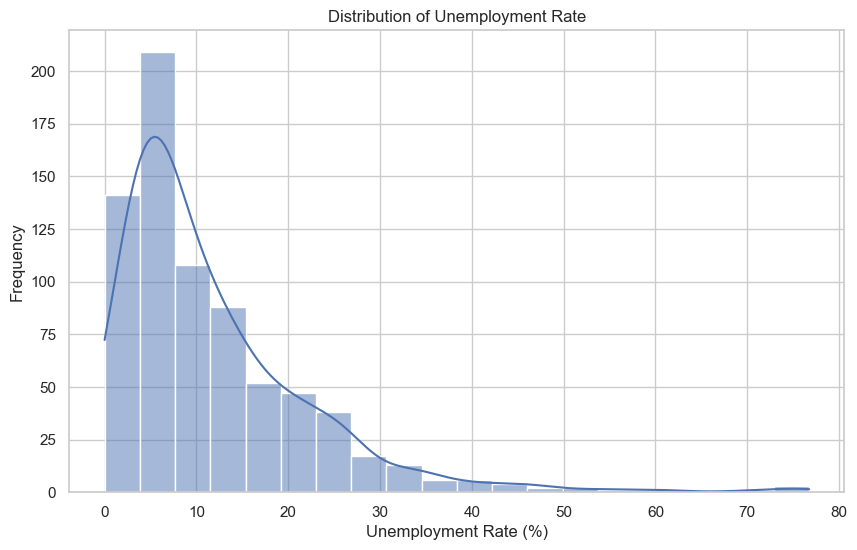

In [28]:
sns.histplot(df['estimated_unemployment_rate_(%)'], bins=20, kde=True)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

<h1>Unemployment Trend Over Time</h1>

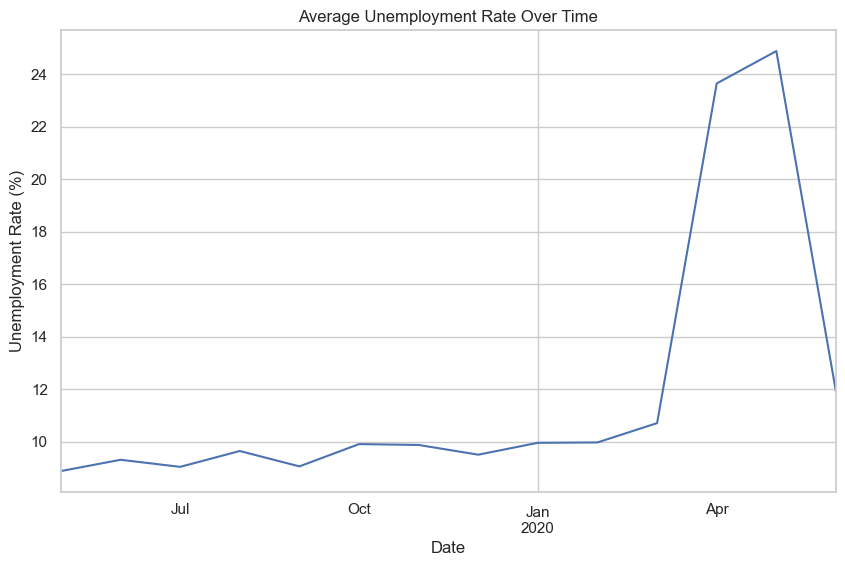

In [29]:
time_trend = df.groupby('date')['estimated_unemployment_rate_(%)'].mean()


time_trend.plot()
plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

<h1>Region-wise Unemployment Comparison</h1>

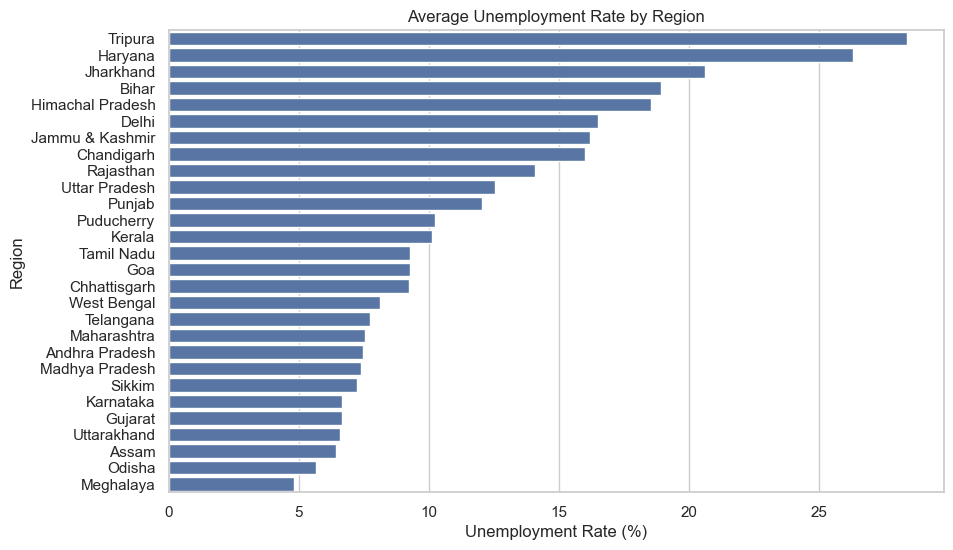

In [30]:
region_avg = df.groupby('region')['estimated_unemployment_rate_(%)'].mean().sort_values(ascending=False)


sns.barplot(x=region_avg.values, y=region_avg.index)
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Region')
plt.show()

<h1>Pre-Covid vs Covid Comparison</h1>

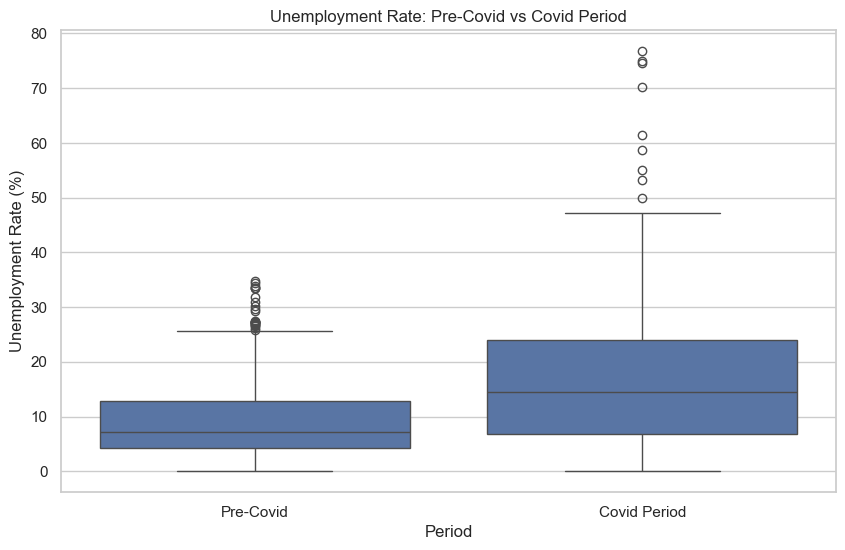

In [31]:
# Create Covid indicator
df['covid_period'] = np.where(df['date'] >= '2020-03-01', 'Covid Period', 'Pre-Covid')


sns.boxplot(x='covid_period', y='estimated_unemployment_rate_(%)', data=df)
plt.title('Unemployment Rate: Pre-Covid vs Covid Period')
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.show()

<h1>***Key Insights & Observations***</h1>

<h3>
*Unemployment rate sharply increased after March 2020

*Covid-19 caused the highest unemployment levels in the dataset

*Certain regions were more affected than others

*Post-lockdown recovery is visible but uneven</h3>

***(Bonus) Correlation Analysis***

<section>
  <h2>Conclusion</h2>
  <p>
    This project analyzed unemployment trends during the Covid-19 pandemic using Python.
    By examining time-series and regional data, the analysis highlighted how the pandemic
    disrupted employment patterns across different regions.
  </p>

  <h3>🔑 Key Takeaways</h3>
  <ul>
    <li>Covid-19 had a severe and measurable impact on employment levels.</li>
    <li>Significant regional disparities exist in unemployment rates.</li>
    <li>Time-series analysis indicates partial recovery patterns after the peak pandemic period.</li>
  </ul>

  <h3>📌 Importance</h3>
  <ul>
    <li>Helps governments design and evaluate employment policies.</li>
    <li>Assists economists in assessing the economic impact of large-scale disruptions.</li>
    <li>Supports data-driven decision-making using real-world labor statistics.</li>
  </ul>

  <h3>⚠️ Limitations</h3>
  <ul>
    <li>The dataset is limited to officially reported unemployment figures.</li>
    <li>The impact on informal and unregistered employment is not fully captured.</li>
  </ul>

  <h3>🚀 Future Improvements</h3>
  <ul>
    <li>Integrate GDP, sector-wise, or industry-level economic data.</li>
    <li>Apply forecasting models to predict future unemployment trends.</li>
    <li>Perform deeper regional clustering to identify structurally similar regions.</li>
  </ul>
</section>


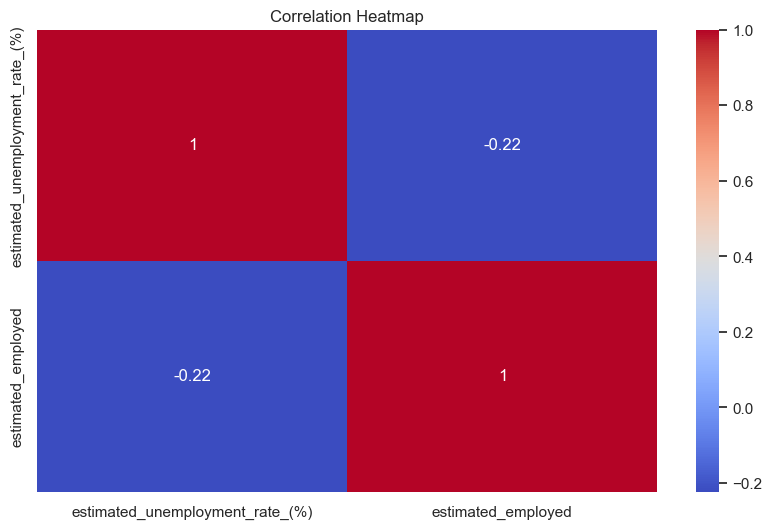

In [34]:
corr = df[['estimated_unemployment_rate_(%)', 'estimated_employed']].corr()


sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [35]:
#Thanks